# Simple baseline (Full Board)

This notebook improves upon the previous baseline by adding piece positions as a feature. To recap, our previous baseline is 58%.

In [82]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import duckdb # we rely on duckdb for parsing movedata
duckdb.sql("LOAD aixchess")

In [41]:
data_path = "subset.parquet"
df = pd.read_parquet(data_path)
df.head()

,lichess_id,tournament,movedata,clocks_white,clocks_black,evals,ply_count,white,black,white_rating,...,time_increment,result,termination,white_rating_diff,black_rating_diff,eco,opening,white_title,black_title,utc_timestamp
0,eh5dKZuD,NaN,b'\xf1\x12\xef\xae\x9c\x86\xe3\x01\xe50\xfe\x9...,"[180, 179, 177, 176, 175, 171, 165, 162, 158, ...","[180, 179, 178, 175, 173, 163, 154, 144, 140, ...",None,29,Panchito0O,PauloPeru78,1247,...,0.0,1-0,Normal,5.0,-5.0,C25,Vienna Game: Anderssen Defense,NaN,NaN,2025-01-01 00:00:05
1,6yXyLl2M,NaN,b'e\x9f\xe3\xbf\xa9\xdc>\x8c\xea[G\x00_k:\xf5)...,"[180, 179, 178, 177, 174, 173, 172, 171, 169, ...","[180, 180, 179, 178, 178, 177, 176, 176, 174, ...",None,104,igloknight,atacan3131,1577,...,0.0,0-1,Time forfeit,-6.0,6.0,B12,Caro-Kann Defense: Masi Variation,NaN,NaN,2025-01-01 00:00:05
2,SZW2amZz,NaN,"b""-\xb4K\xb2C\xdf\xa3Wem\x88(\xfe'|\x93\xa2Q`\...","[180, 179, 179, 177, 175, 173, 172, 171, 169, ...","[180, 178, 175, 174, 173, 171, 169, 168, 163, ...",None,87,draughts2chess,xhoxhi64,1043,...,0.0,1-0,Normal,10.0,-5.0,D00,Queen's Pawn Game,NaN,NaN,2025-01-01 00:00:05
3,VGhr7swl,NaN,b'\xb3s\xaff\x0b\x8c|\x94\xf7\xcb\xbb\xa7\xb22...,"[180, 176, 174, 172, 168, 167, 165, 158, 142, ...","[180, 180, 180, 179, 177, 176, 176, 166, 158, ...",None,58,GodofPastries,Mickey187,2015,...,0.0,1-0,Normal,6.0,-11.0,B13,Caro-Kann Defense: Exchange Variation,NaN,NaN,2025-01-01 00:00:05
4,aQTAJkjw,NaN,b'\xb3\xc9\xf7\xbf\xf4\x11\xde\x9e\x85*\x97\xc...,"[180, 179, 179, 177, 177, 177, 176, 176, 176, ...","[180, 178, 177, 177, 177, 175, 173, 172, 171, ...",None,112,elprimo27,knocikIII,2139,...,0.0,0-1,Normal,-6.0,5.0,B10,Caro-Kann Defense: Endgame Variation,NaN,NaN,2025-01-01 00:00:05


In [42]:
games = duckdb.read_parquet("subset.parquet")

game_positions = duckdb.sql("""
SELECT
  lc.* EXCLUDE (movedata, clocks_white, clocks_black, tournament), 
  t.ply,
  UNNEST(board_at_position(lc.movedata, t.ply))
FROM games AS lc
CROSS JOIN LATERAL (
  SELECT 1 + CAST(floor(random() * lc.ply_count) AS INTEGER) AS ply
) AS t
""")
df = game_positions.df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [97]:
def preprocess_df(df):
    # Select out the features and labels
    labels = 'result'
    
    categorical_features = [chr(file+ord('a'))+str(rank+1) for rank in range(8) for file in range(8)]
    features = ['white_rating', 'black_rating', 'ply']
    
    one_hot_df = pd.DataFrame({f'{col}_{piece}': df[col] == piece for piece in list('prnbqkPRNBQK') for col in categorical_features})
    X_df = pd.concat([df[features], one_hot_df], axis='columns')
    X_df['ply'] = (X_df['ply'] % 2 == 0)
    X_df['white_rating'] = (X_df['white_rating'] - 1500) / 400 # condition ratings to be same scale as one-hots for optimizer
    X_df['black_rating'] = (X_df['black_rating'] - 1500) / 400 # condition ratings for optimizer

    y_df = df[labels]
    return X_df, y_df

# Note: this function has changed from the previous notebook
def preprocess(X_df, y_df, test_size=0.2, random_state=None):
    X, y = X_df.to_numpy(), y_df.to_numpy()
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def train_baseline(X_train, y_train, max_iter=10000) -> LogisticRegression:
    model = LogisticRegression(max_iter=max_iter)
    model.fit(X_train, y_train)
    return model

def eval_model(model, X_test, y_test):
    y_preds = model.predict(X_test)
    num_correct = (y_preds == y_test).sum()
    total = y_test.shape[0]
    print(f"Accuracy: {num_correct}/{total} = {(num_correct / total):.3f}")
    return dict(num_correct=num_correct, total=total, accuracy=num_correct / total)



In [98]:
X_df, y_df = preprocess_df(df)
X_train, X_test, y_train, y_test = preprocess(X_df, y_df, random_state=0)
model = train_baseline(X_train, y_train, max_iter=100000)
_ = eval_model(model, X_test, y_test)

Accuracy: 12226/20000 = 0.611


### Accuracy jump, weight visualization

We've improved accuracy again just by adding piece positions (58% -> 61%). So, this means that our model is benefitting from knowing _where_ pieces are positioned.
To illustrate, let's visualize the weight matrix for all board positions for a piece, such as the white knight.

In [99]:
model.classes_

array(['0-1', '1-0', '1/2-1/2'], dtype=object)

In [100]:
model.coef_

array([[-6.24647268e-01,  5.86852227e-01,  4.69886090e-02, ...,
         4.59923614e-04, -2.21226087e-01, -1.25861644e-01],
       [ 6.91982979e-01, -7.45402782e-01, -1.98772078e-01, ...,
        -3.26666533e-01, -5.07042665e-01, -4.32887099e-01],
       [-6.73357114e-02,  1.58550555e-01,  1.51783469e-01, ...,
         3.26206610e-01,  7.28268752e-01,  5.58748743e-01]],
      shape=(3, 771))

In [101]:
# so, let's assume we want to determine the win rate for white depending on the position the knight.
(row), = np.where(model.classes_ == '1-0') # coeffs associate with white win
(start_col, end_col), = np.where((X_df.columns == 'a1_N') | (X_df.columns == 'h8_N')) # features associated with the knight position
row, start_col, end_col

(array([1]), np.int64(515), np.int64(578))

In [102]:
model.coef_[row, start_col:end_col+1].reshape(8,8)

array([[ 0.14020123,  0.21000405,  0.2856806 , -0.05878358,  0.06999297,
         0.46166546,  0.25775057,  0.44874191],
       [ 0.16053379,  0.42920084,  0.14687191,  0.30958295,  0.21860606,
         0.01713232,  0.25956646,  0.04194981],
       [ 0.20164066,  0.28738066,  0.20252576,  0.40017767,  0.03869418,
         0.18909523,  0.26598468,  0.18093361],
       [ 0.15575947,  0.21156163,  0.28895642,  0.24725011,  0.28067014,
         0.35748444,  0.23419922,  0.12218808],
       [ 0.30160394,  0.28755921,  0.37533153,  0.4136968 ,  0.24605745,
         0.30921969,  0.40468493,  0.6791788 ],
       [ 0.28251455,  0.24578336,  0.28262597,  0.37524659,  0.40993196,
         0.47927943,  0.1870852 ,  0.68713992],
       [ 0.74301267,  0.23275389,  0.42938628,  0.52362512,  0.38988079,
         0.79307145,  0.279206  , -0.02201011],
       [ 0.20877878, -0.07013544,  0.27119986,  0.36955897,  0.59827198,
        -0.14655737,  0.10642793,  0.5810402 ]])

In [103]:
X_df.columns[start_col:end_col+1]

Index(['a1_N', 'b1_N', 'c1_N', 'd1_N', 'e1_N', 'f1_N', 'g1_N', 'h1_N', 'a2_N',
       'b2_N', 'c2_N', 'd2_N', 'e2_N', 'f2_N', 'g2_N', 'h2_N', 'a3_N', 'b3_N',
       'c3_N', 'd3_N', 'e3_N', 'f3_N', 'g3_N', 'h3_N', 'a4_N', 'b4_N', 'c4_N',
       'd4_N', 'e4_N', 'f4_N', 'g4_N', 'h4_N', 'a5_N', 'b5_N', 'c5_N', 'd5_N',
       'e5_N', 'f5_N', 'g5_N', 'h5_N', 'a6_N', 'b6_N', 'c6_N', 'd6_N', 'e6_N',
       'f6_N', 'g6_N', 'h6_N', 'a7_N', 'b7_N', 'c7_N', 'd7_N', 'e7_N', 'f7_N',
       'g7_N', 'h7_N', 'a8_N', 'b8_N', 'c8_N', 'd8_N', 'e8_N', 'f8_N', 'g8_N',
       'h8_N'],
      dtype='str')

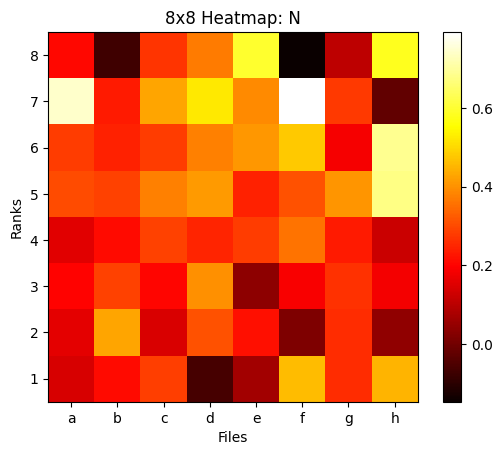

In [111]:
board = model.coef_[row, start_col:end_col+1].reshape(8,8)[::-1, :]

fig, ax = plt.subplots()

im = ax.imshow(board, cmap='hot', interpolation='nearest')
plt.colorbar(im)

# Chess labels
files = list("abcdefgh")
ranks = list(range(1,9))

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))

ax.set_xticklabels(files)
ax.set_yticklabels(ranks[::-1])

ax.set_xlabel("Files")
ax.set_ylabel("Ranks")

plt.title("8x8 Heatmap: N")
plt.show()

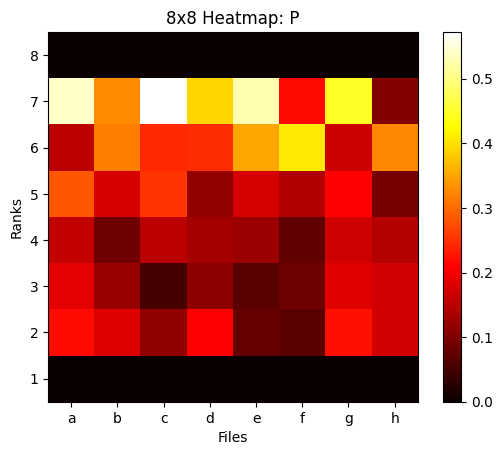

In [108]:
# Not as strong as I thought. Let's extract the above into a reusable function and then we can try some other pieces.
def plot_piece_heatmap(piece_name='N', result='1-0'):
    # so, let's assume we want to determine the win rate for white depending on the position the knight.
    (row), = np.where(model.classes_ == result) # coeffs associate with white win
    (start_col, end_col), = np.where((X_df.columns == f'a1_{piece_name}') | (X_df.columns == f'h8_{piece_name}')) # features associated with the knight position

    board = model.coef_[row, start_col:end_col+1].reshape(8,8)[::-1, :]

    fig, ax = plt.subplots()
    
    im = ax.imshow(board, cmap='hot', interpolation='nearest')
    plt.colorbar(im)
    
    # Chess labels
    files = list("abcdefgh")
    ranks = list(range(1,9))
    
    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    
    ax.set_xticklabels(files)
    ax.set_yticklabels(ranks[::-1])
    
    ax.set_xlabel("Files")
    ax.set_ylabel("Ranks")
    
    plt.title(f"8x8 Heatmap: {piece_name}")
    plt.show()

plot_piece_heatmap(piece_name='P')

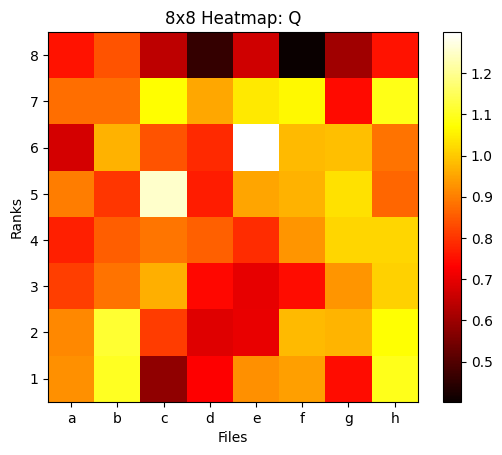

In [109]:
plot_piece_heatmap(piece_name='Q')

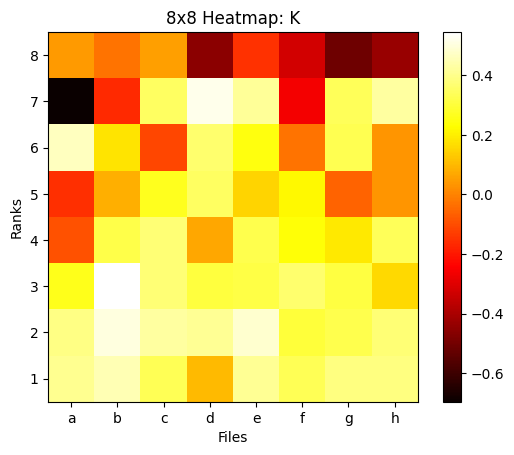

In [110]:
plot_piece_heatmap(piece_name='K')

## Conclusion

We've seen plots of how piece placement affects win probability in real games. The next logical step is to understand the non-linearities -- A knight on f7 is probably good if it is forking a king and rook, but probably bad if f7 is defended. To that end, let's try switching to a new model -- gradient boosting with XGBoost.